# Market Risk Lab – Zadanie Domowe 2
## Value at Risk: metody historyczna i parametryczna

**Autor:** Oleksandra Krykun – oleksandrakrykun2@gmail.com  
**Data:** 22 kwietnia 2026  
**Kurs:** Market Risk Lab  

---

## 1. Import bibliotek i pobranie danych

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold'
})

TICKERS = ['GS', 'C', 'AIG', 'BAC', 'MS']
NAMES   = {'GS': 'Goldman Sachs', 'C': 'Citigroup',
           'AIG': 'AIG', 'BAC': 'Bank of America', 'MS': 'Morgan Stanley'}
START   = '2006-08-01'
END     = '2008-07-31'
COLORS  = ['#2196F3', '#E91E63', '#FF5722', '#4CAF50', '#9C27B0']

In [2]:
data = yf.download(TICKERS, start = START, end = END, auto_adjust=False)["Adj Close"]
data = data[TICKERS]
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,GS,C,AIG,BAC,MS
Date,,,,,
2006-08-01,110.278679,317.385437,727.275635,34.087536,35.916286
2006-08-02,109.287140,318.759369,726.432129,34.371998,36.074265
2006-08-03,110.891159,320.345520,722.696289,34.378609,36.929405
2006-08-04,111.540001,320.543610,723.901550,34.610123,36.869480
2006-08-07,111.292061,318.759308,720.768372,34.504303,36.569901


## 2. Logarytmiczne stopy zwrotu

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

In [3]:
log_ret = np.log(data / data.shift(1)).dropna()
log_ret.head()

Ticker,GS,C,AIG,BAC,MS
Date,,,,,
2006-08-02,-0.009032,0.004320,-0.001160,0.008310,0.004389
2006-08-03,0.014570,0.004964,-0.005156,0.000192,0.023428
2006-08-04,0.005834,0.000618,0.001666,0.006712,-0.001624
2006-08-07,-0.002225,-0.005582,-0.004338,-0.003062,-0.008159
2006-08-08,-0.007892,0.001657,-0.002176,-0.001920,-0.012891


## 3. Definicja portfeli

- **Portfel A – równe wagi:** każda z 5 spółek ma wagę 20%.
- **Portfel B – losowe wagi:** wagi wylosowane z rozkładu Dirichleta (suma = 1), z ustalonym ziarnem dla powtarzalności wyników.

Stopy zwrotu portfela obliczamy jako ważoną sumę log-stóp zwrotu poszczególnych akcji (aproksymacja dokładna dla małych zmian).

In [4]:
np.random.seed(123) # dla powtarzalności wyników

w_A = np.array([1/5] * 5)
w_B = np.random.dirichlet(np.ones(5))

port_ret_A = (log_ret * w_A).sum(axis=1)
port_ret_B = (log_ret * w_B).sum(axis=1)

print('Wagi portfeli:')
print(f'{"Ticker":<8}{"Portfel A (równe)":<22}{"Portfel B (losowe)"}')
print('-' * 48)
for t, wa, wb in zip(TICKERS, w_A, w_B):
    print(f'{t:<8}{wa*100:>10.1f}%{" ":>10}{wb*100:>10.2f}%')
print(f'{"SUMA":<8}{sum(w_A)*100:>10.1f}%{" ":>10}{sum(w_B)*100:>10.2f}%')
print(f'\nŁączna liczba obserwacji stóp zwrotu: {len(port_ret_A)}')
print(f'Zakres dat: {port_ret_A.index[0].date()} – {port_ret_A.index[-1].date()}')

Wagi portfeli:
Ticker  Portfel A (równe)     Portfel B (losowe)
------------------------------------------------
GS            20.0%               30.89%
C             20.0%                8.73%
AIG           20.0%                6.67%
BAC           20.0%               20.77%
MS            20.0%               32.94%
SUMA         100.0%              100.00%

Łączna liczba obserwacji stóp zwrotu: 502
Zakres dat: 2006-08-02 – 2008-07-30


## 4. Okno 250 dni roboczych

VaR wyznaczamy z **ostatnich 250 dni roboczych** – standardowe okno wymagane przez Basel II/III.

Okno 250 dni: 2007-08-03 – 2008-07-30
Liczba obserwacji: 250


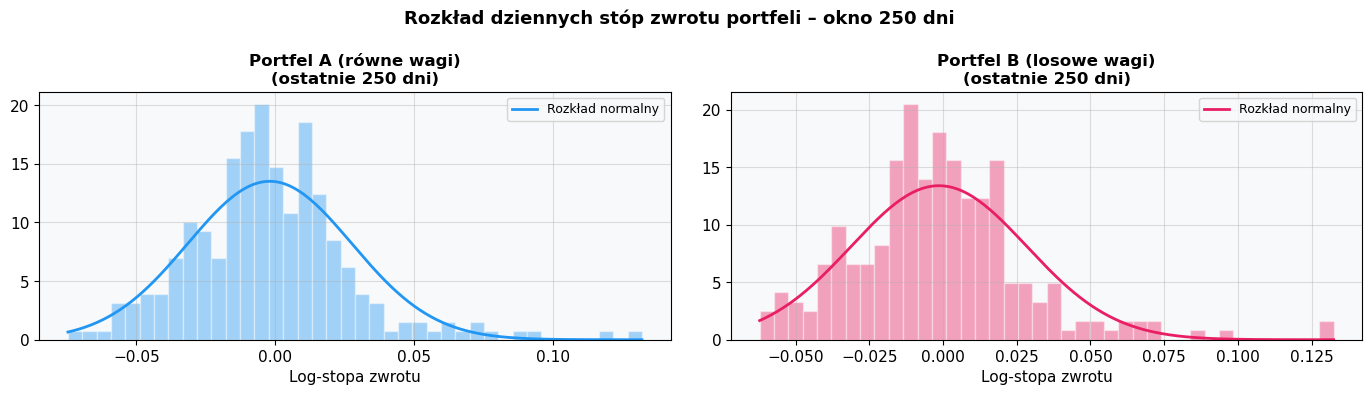

In [5]:
WINDOW = 250
ret_A_250 = port_ret_A.iloc[-WINDOW:]
ret_B_250 = port_ret_B.iloc[-WINDOW:]

print(f'Okno 250 dni: {ret_A_250.index[0].date()} – {ret_A_250.index[-1].date()}')
print(f'Liczba obserwacji: {len(ret_A_250)}')

# Przegląd rozkładu stóp zwrotu portfeli
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, ret, label, color in zip(axes,
                                  [ret_A_250, ret_B_250],
                                  ['Portfel A (równe wagi)', 'Portfel B (losowe wagi)'],
                                  ['#2196F3', '#E91E63']):
    ax.hist(ret, bins=40, color=color, alpha=0.4, edgecolor='white', density=True)
    x = np.linspace(ret.min(), ret.max(), 200)
    ax.plot(x, stats.norm.pdf(x, ret.mean(), ret.std()), color=color, lw=2, label='Rozkład normalny')
    ax.set_title(f'{label}\n(ostatnie 250 dni)', fontsize=12)
    ax.set_xlabel('Log-stopa zwrotu')
    ax.legend(fontsize=9)
fig.suptitle('Rozkład dziennych stóp zwrotu portfeli – okno 250 dni', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('portfele_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Historyczny VaR (metoda symulacji historycznej)

**Idea:** VaR historyczny to empiryczny kwantyl rozkładu stóp zwrotu portfela z okna historycznego.  
Nie zakładamy żadnego rozkładu parametrycznego – używamy bezpośrednio zaobserwowanych zmian wartości.

$$\text{VaR}_{\alpha}^{\text{hist}} = -Q_{1-\alpha}(r_1, r_2, \ldots, r_{250})$$

gdzie $Q_{1-\alpha}$ oznacza kwantyl rzędu $(1-\alpha)$ empirycznego rozkładu stóp zwrotu.  

Dla poziomu ufności 95%: szukamy 5. percentyla (5% najgorszych wyników), tj. 12–13 najgorszy wynik z 250.  
Dla poziomu ufności 99%: szukamy 1. percentyla, tj. 2–3 najgorszy wynik z 250.

Historyczny VaR (jako % wartości portfela):
Portfel          VaR 95%     VaR 99%
------------------------------------
Portfel A         4.751%       5.996%
Portfel B         4.590%       5.886%


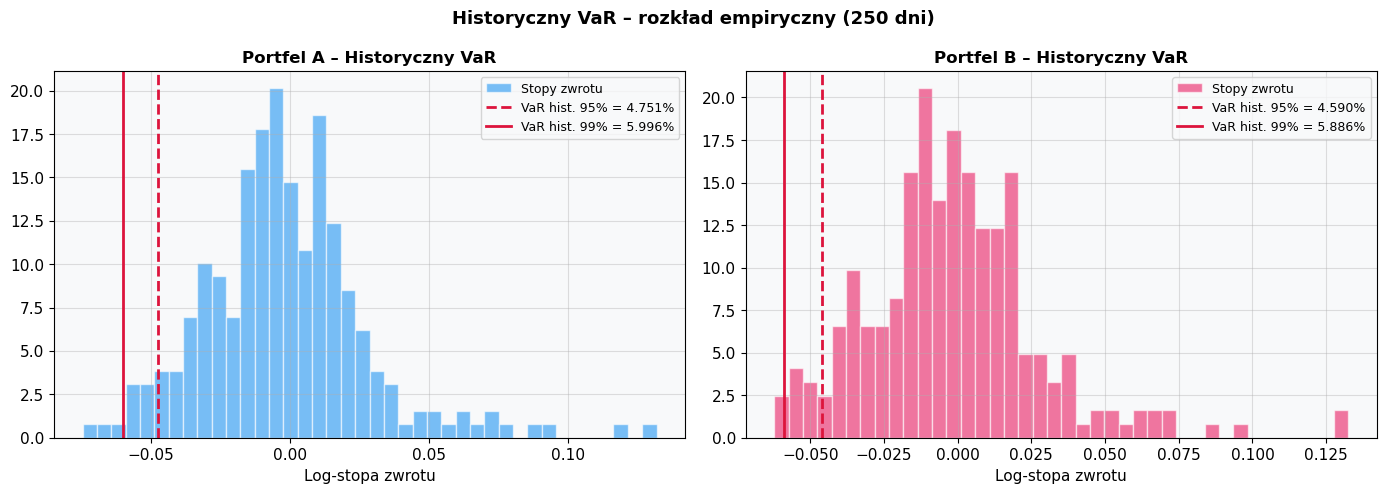

In [6]:
CONF_LEVELS = [0.95, 0.99]

var_hist = {}
for label, ret in [('A', ret_A_250), ('B', ret_B_250)]:
    var_hist[label] = {}
    for cl in CONF_LEVELS:
        var_hist[label][cl] = -np.quantile(ret, 1 - cl)

print('Historyczny VaR (jako % wartości portfela):')
print(f'{"Portfel":<12}{"VaR 95%":>12}{"VaR 99%":>12}')
print('-' * 36)
for label in ['A', 'B']:
    v95 = var_hist[label][0.95]
    v99 = var_hist[label][0.99]
    print(f'Portfel {label:<5}{v95*100:>10.3f}%{v99*100:>12.3f}%')

# Wizualizacja – histogram z zaznaczonymi VaR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ret, label, color in zip(axes,
                                  [ret_A_250, ret_B_250],
                                  ['A', 'B'],
                                  ['#2196F3', '#E91E63']):
    ax.hist(ret, bins=40, color=color, alpha=0.6, edgecolor='white',
            label='Stopy zwrotu', density=True)
    for cl, ls, lbl in [(0.95, '--', '95%'), (0.99, '-', '99%')]:
        v = var_hist[label][cl]
        ax.axvline(-v, color='crimson', linestyle=ls, linewidth=2,
                   label=f'VaR hist. {lbl} = {v*100:.3f}%')
    ax.set_title(f'Portfel {label} – Historyczny VaR', fontsize=12)
    ax.set_xlabel('Log-stopa zwrotu')
    ax.legend(fontsize=9)
fig.suptitle('Historyczny VaR – rozkład empiryczny (250 dni)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('var_historyczny.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Parametryczny VaR (metoda analityczna, założenie rozkładu normalnego)

**Idea:** Zakładamy, że stopy zwrotu portfela mają rozkład normalny $\mathcal{N}(\mu, \sigma^2)$.  
VaR wyznaczamy analitycznie ze wzoru:

$$\text{VaR}_{\alpha}^{\text{param}} = -(\mu - z_{\alpha} \cdot \sigma)$$

gdzie $z_{\alpha}$ to kwantyl standardowego rozkładu normalnego:
- dla $\alpha = 95\%$: $z_{0.05} \approx 1{,}645$
- dla $\alpha = 99\%$: $z_{0.01} \approx 2{,}326$

$\mu$ i $\sigma$ estymujemy z 250-dniowego okna historycznego.

Parametryczny VaR (jako % wartości portfela):
Portfel          VaR 95%     VaR 99%    μ dzienna     σ dzienna
-----------------------------------------------------------------
Portfel A         5.059%       7.073%   -0.2004%      2.9540%
Portfel B         5.040%       7.070%   -0.1409%      2.9784%


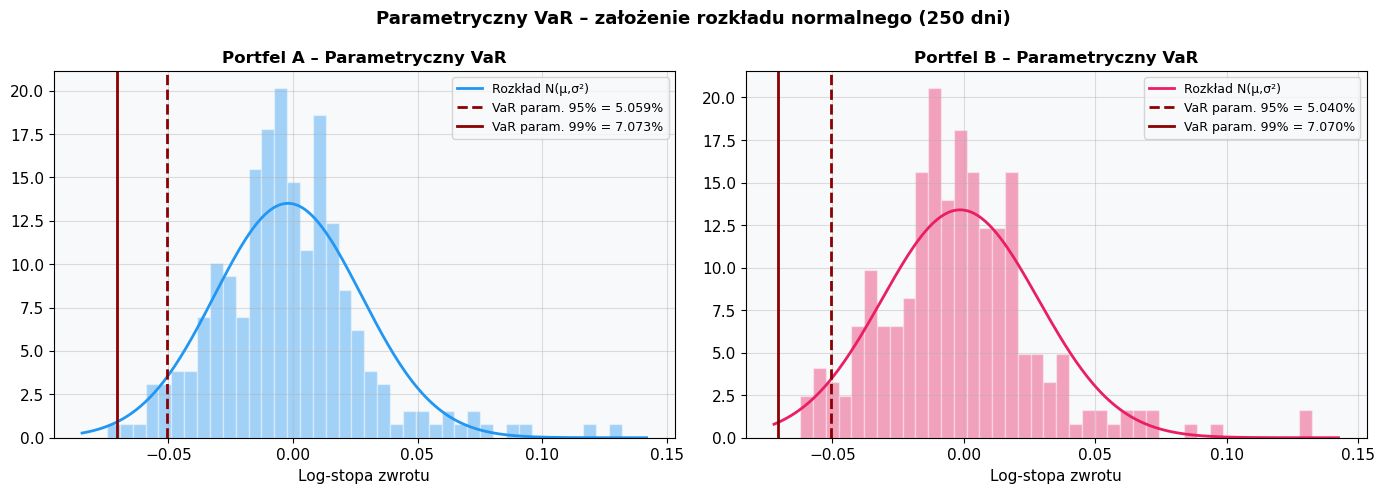

In [7]:
var_param = {}
for label, ret in [('A', ret_A_250), ('B', ret_B_250)]:
    var_param[label] = {}
    for cl in CONF_LEVELS:
        mu = ret.mean()
        sig = ret.std()
        z = stats.norm.ppf(1 - cl)
        var_param[label][cl] = -(mu + z * sig)

print('Parametryczny VaR (jako % wartości portfela):')
print(f'{"Portfel":<12}{"VaR 95%":>12}{"VaR 99%":>12}    μ dzienna     σ dzienna')
print('-' * 65)
for label, ret in [('A', ret_A_250), ('B', ret_B_250)]:
    print(f'Portfel {label:<5}{var_param[label][0.95]*100:>10.3f}%{var_param[label][0.99]*100:>12.3f}%  {ret.mean()*100:>8.4f}%  {ret.std()*100:>10.4f}%')

# Wizualizacja – gęstość normalna z zaznaczonymi VaR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, ret, label, color in zip(axes,
                                  [ret_A_250, ret_B_250],
                                  ['A', 'B'],
                                  ['#2196F3', '#E91E63']):
    mu, sig = ret.mean(), ret.std()
    x = np.linspace(ret.min() - 0.01, ret.max() + 0.01, 300)
    ax.plot(x, stats.norm.pdf(x, mu, sig), color=color, lw=2, label='Rozkład N(μ,σ²)')
    ax.hist(ret, bins=40, density=True, color=color, alpha=0.4, edgecolor='white')
    for cl, ls, lbl in [(0.95, '--', '95%'), (0.99, '-', '99%')]:
        v = var_param[label][cl]
        ax.axvline(-v, color='darkred', linestyle=ls, linewidth=2,
                   label=f'VaR param. {lbl} = {v*100:.3f}%')
    ax.set_title(f'Portfel {label} – Parametryczny VaR', fontsize=12)
    ax.set_xlabel('Log-stopa zwrotu')
    ax.legend(fontsize=9)
fig.suptitle('Parametryczny VaR – założenie rozkładu normalnego (250 dni)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('var_parametryczny.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Porównanie wyników

In [8]:
rows = []
for label in ['A', 'B']:
    for cl in CONF_LEVELS:
        vh = var_hist[label][cl]
        vp = var_param[label][cl]
        rows.append({
            'Portfel': f'Portfel {label}',
            'Poziom ufnosci': f'{int(cl*100)}%',
            'VaR historyczny': f'{vh*100:.4f}%',
            'VaR parametryczny': f'{vp*100:.4f}%',
            'Roznica (param - hist)': f'{(vp - vh)*100:+.4f}%'
        })

comparison = pd.DataFrame(rows)
print('Porownanie VaR – metoda historyczna vs. parametryczna\n')
display(comparison.set_index(['Portfel', 'Poziom ufnosci']))

Porownanie VaR – metoda historyczna vs. parametryczna



VaR historyczny VaR parametryczny  \
Portfel   Poziom ufnosci                                     
Portfel A 95%                    4.7511%           5.0594%   
          99%                    5.9958%           7.0725%   
Portfel B 95%                    4.5904%           5.0400%   
          99%                    5.8858%           7.0698%   

                         Roznica (param - hist)  
Portfel   Poziom ufnosci                         
Portfel A 95%                          +0.3083%  
          99%                          +1.0767%  
Portfel B 95%                          +0.4496%  
          99%                          +1.1840%

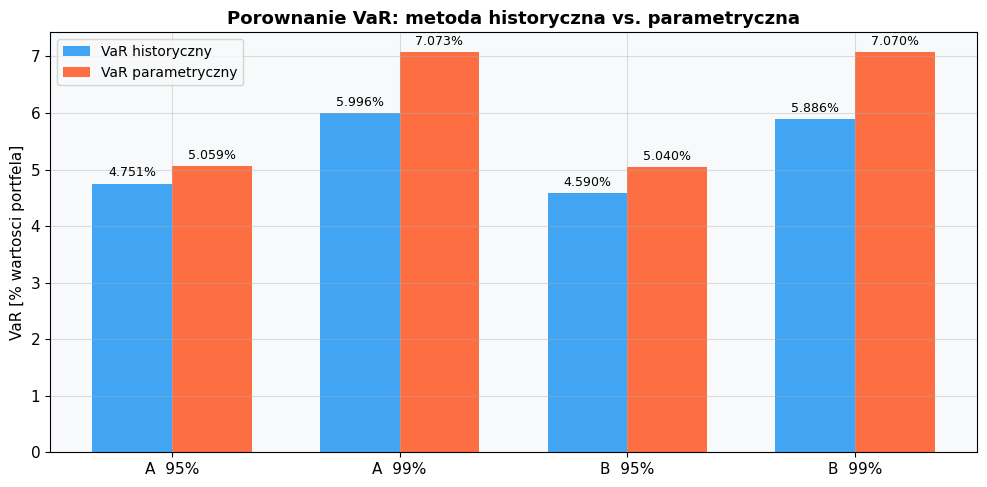

In [9]:
labels_plot = ['A  95%', 'A  99%', 'B  95%', 'B  99%']
vals_hist  = [var_hist['A'][0.95]*100,  var_hist['A'][0.99]*100,
              var_hist['B'][0.95]*100,  var_hist['B'][0.99]*100]
vals_param = [var_param['A'][0.95]*100, var_param['A'][0.99]*100,
              var_param['B'][0.95]*100, var_param['B'][0.99]*100]

x = np.arange(len(labels_plot))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, vals_hist,  w, label='VaR historyczny',
            color='#2196F3', alpha=0.85)
b2 = ax.bar(x + w/2, vals_param, w, label='VaR parametryczny',
            color='#FF5722', alpha=0.85)
ax.bar_label(b1, fmt='%.3f%%', fontsize=9, padding=3)
ax.bar_label(b2, fmt='%.3f%%', fontsize=9, padding=3)
ax.set_xticks(x)
ax.set_xticklabels(labels_plot)
ax.set_ylabel('VaR [% wartosci portfela]')
ax.set_title('Porownanie VaR: metoda historyczna vs. parametryczna',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('var_porownanie.png', dpi=120, bbox_inches='tight')
plt.show()

In [10]:
print('Statystyki portfeli (okno 250 dni):')
print(f'{"Miara":<35}{"Portfel A":>15}{"Portfel B":>15}')
print('-' * 65)
miary = [
    ('Srednia dzienna',
     f'{ret_A_250.mean()*100:.4f}%', f'{ret_B_250.mean()*100:.4f}%'),
    ('Odch. std. dzienna',
     f'{ret_A_250.std()*100:.4f}%',  f'{ret_B_250.std()*100:.4f}%'),
    ('Skosnosc',
     f'{ret_A_250.skew():.4f}',      f'{ret_B_250.skew():.4f}'),
    ('Kurtoza (excess)',
     f'{ret_A_250.kurtosis():.4f}',  f'{ret_B_250.kurtosis():.4f}'),
    ('Min (najgorszy dzien)',
     f'{ret_A_250.min()*100:.4f}%',  f'{ret_B_250.min()*100:.4f}%'),
    ('VaR hist. 95%',
     f'{var_hist["A"][0.95]*100:.4f}%', f'{var_hist["B"][0.95]*100:.4f}%'),
    ('VaR hist. 99%',
     f'{var_hist["A"][0.99]*100:.4f}%', f'{var_hist["B"][0.99]*100:.4f}%'),
    ('VaR param. 95%',
     f'{var_param["A"][0.95]*100:.4f}%', f'{var_param["B"][0.95]*100:.4f}%'),
    ('VaR param. 99%',
     f'{var_param["A"][0.99]*100:.4f}%', f'{var_param["B"][0.99]*100:.4f}%'),
]
for nazwa, va, vb in miary:
    print(f'{nazwa:<35}{va:>15}{vb:>15}')

Statystyki portfeli (okno 250 dni):
Miara                                    Portfel A      Portfel B
-----------------------------------------------------------------
Srednia dzienna                           -0.2004%       -0.1409%
Odch. std. dzienna                         2.9540%        2.9784%
Skosnosc                                    0.9266         1.0200
Kurtoza (excess)                            2.8097         2.9424
Min (najgorszy dzien)                     -7.4661%       -6.2229%
VaR hist. 95%                              4.7511%        4.5904%
VaR hist. 99%                              5.9958%        5.8858%
VaR param. 95%                             5.0594%        5.0400%
VaR param. 99%                             7.0725%        7.0698%


## 8. Wnioski

### Który portfel jest mniej ryzykowny?

Okno 250 dni obejmuje **sierpień 2007 – lipiec 2008** – fazę narastającego kryzysu finansowego po sygnale BNP Paribas (9 sierpnia 2007 r. zamroził wypłaty z trzech funduszy hedgingowych). Oba portfele zawierają te same 5 spółek przy różnych wagach.

**Portfel B (losowe wagi) jest nieznacznie mniej ryzykowny** według obu metod i obu poziomów ufności:

| Miara | Portfel A | Portfel B |
|-------|-----------|----------|
| VaR hist. 95% | 4,7511% | 4,5904% |
| VaR hist. 99% | 5,9958% | 5,8858% |
| VaR param. 95% | 5,0594% | 5,0400% |
| VaR param. 99% | 7,0725% | 7,0698% |
| σ dzienna | 2,9540% | 2,9784% |

Wylosowane wagi Portfela B koncentrują się na GS (30,89%) i MS (32,94%) – bankach inwestycyjnych, które w tym oknie czasowym radziły sobie relatywnie lepiej od Citigroup i AIG. Niższa ekspozycja na AIG (6,67%) i C (8,73%) – spółki z największymi stratami w tym okresie – przełożyła się na niższe empiryczne straty ogonowe. Odchylenie standardowe Portfela B jest jednak nieznacznie **wyższe** (2,9784% vs 2,9540%), co oznacza, że portfel B jest bardziej zmienny na co dzień, lecz ma łagodniejsze skrajne obserwacje. Różnice są rzędu 0,01–0,3 pp ze względu na wysokie korelacje między spółkami sektora finansowego w warunkach kryzysu – dywersyfikacja wewnątrzsektorowa jest ograniczona niezależnie od wag.

### Metoda historyczna vs. parametryczna

Wyniki ujawniają charakterystyczną asymetrię między metodami:

**Na poziomie 95%** VaR historyczny jest **niższy** niż parametryczny (Portfel A: 4,75% vs 5,06%; Portfel B: 4,59% vs 5,04%). Środkowa część empirycznego rozkładu jest zbliżona do normalnej – model gaussowski nieznacznie zawyża ryzyko w tym obszarze.

**Na poziomie 99%** VaR historyczny jest nadal **niższy** niż parametryczny (Portfel A: 5,99% vs 7,07%; Portfel B: 5,89% vs 7,07%). Pozornie zaskakujące – w warunkach kryzysu spodziewalibyśmy się odwrotnego wyniku (grube ogony → wyższy VaR historyczny). Przyczyną jest **dodatnia skośność** obu portfeli w tym oknie (Portfel A: 0,93; Portfel B: 1,02). Okno 2007–2008 zawierało nie tylko silne spadki, ale i gwałtowne odbicia (marzec 2008 po Bear Stearns, lipiec 2008). Te duże dodatnie zwroty przesuwają rozkład w prawo, podczas gdy model normalny zakłada symetrię – przez co symetryczny lewy ogon gaussowski jest grubszy niż empiryczny, dając wyższy VaR 99% parametryczny.

**Kurtoza** obu portfeli wynosi ~2,8–2,9 (blisko wartości 3 dla rozkładu normalnego, nadmiarowa kurtoza ≈ 0) – ogony empiryczne nie są drastycznie grubsze od normalnych. Gdyby kurtoza była wyraźnie wyższa, VaR historyczny 99% przekroczyłby parametryczny.

**Ogólny wniosek:** Wybór metody ma istotne znaczenie, szczególnie na wysokich poziomach ufności. Metoda historyczna jest czuła na konkretny skład okna i specyfikę rozkładu (skośność, kurtoza). Metoda parametryczna może zarówno niedoszacowywać ryzyko (grube ogony), jak i przeszacowywać je (dodatnia skośność) – zależnie od faktycznego kształtu rozkładu. W analizowanym przypadku kryzysowego okna 2007–2008 model gaussowski przeszacowuje ryzyko ogonowe ze względu na asymetrię rozkładu.